# Cambridge sampler — historical ballot lengths

VoteKit's Cambridge model doesn't invent ballot shapes. It ships the empirical
distribution of *ballot types* from Cambridge, MA municipal elections,
2009–2017, and samples from it. A ballot type is the sequence of slates a voter
ranked — `WWCW` means they ranked a W candidate, then another W, then a C, then
a W — with W the historical majority slate and C the minority.

Two files ship with the package, split by which slate the ballot starts with:

```
votekit/ballot_generator/bloc_slate_generator/data/
├── Cambridge_09to17_ballot_types_start_with_W_ballots_distribution.json
└── Cambridge_09to17_ballot_types_start_with_C_ballots_distribution.json
```

This notebook loads both and looks at how long those ballots are.

**Where the binomial actually is.** It governs *which file a voter draws from*,
not how long their ballot is — in `_sample_cambridge_slate_ballots`:

```python
num_ballots_start_with_maj_slate = np.random.binomial(
    n_ballots, p=config.cohesion_df[majority_bloc].loc[bloc]
)
```

Each voter flips a coin weighted by their bloc's cohesion to decide whether
their first choice is a majority- or minority-slate candidate; the rest of the
ballot, length included, is then drawn wholesale from the historical
distribution. Length is empirical, and as the fit below shows, decidedly not
binomial.

In [1]:
import collections
import json
import sys
from importlib.resources import files
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binom

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

from pipeline.summarize_results import BAR_EDGE_COLOR, MODE_COLORS  # noqa: E402
from pipeline.utils.helpers import load_run_config  # noqa: E402

DATA_DIR = files("votekit.ballot_generator.bloc_slate_generator") / "data"
HIST_SLATES = {"W": "Historical majority (W)", "C": "Historical minority (C)"}

pmfs = {
    tag: json.loads(
        (DATA_DIR / f"Cambridge_09to17_ballot_types_start_with_{tag}_ballots_distribution.json").read_text()
    )
    for tag in HIST_SLATES
}

ballots = pd.DataFrame(
    [
        {
            "starts_with": tag,
            "ballot_type": ballot,
            "length": len(ballot),
            "probability": prob,
            "n_majority": ballot.count("W"),
            "n_minority": ballot.count("C"),
        }
        for tag, pmf in pmfs.items()
        for ballot, prob in pmf.items()
    ]
)
print(f"{len(ballots):,} distinct ballot types")
print(ballots.groupby("starts_with")["probability"].agg(["count", "sum"]).round(4).to_string())
ballots.head()

8,559 distinct ballot types
             count  sum
starts_with            
C             3940  1.0
W             4619  1.0


,starts_with,ballot_type,length,probability,n_majority,n_minority
0,W,WWW,3,0.057471,3,0
1,W,WWWCWCWCCWWWWWWWWWCC,20,0.000019,14,6
2,W,WCWWWWWCWW,10,0.000057,8,2
3,W,WWWCWWWCCCCWWWWWWWWC,20,0.000019,14,6
4,W,WWCWW,5,0.009575,4,1


## The length distribution

Each ballot type carries a probability, so the length distribution is those
probabilities pooled by length rather than a count of rows.

In [2]:
def length_pmf(df: pd.DataFrame) -> pd.Series:
    """P(ballot length), renormalized over whatever slice is passed in."""
    pmf = df.groupby("length")["probability"].sum()
    return (pmf / pmf.sum()).sort_index()


def moments(pmf: pd.Series) -> dict:
    lengths = pmf.index.to_numpy(dtype=float)
    mean = float((lengths * pmf.to_numpy()).sum())
    var = float((((lengths - mean) ** 2) * pmf.to_numpy()).sum())
    return {"mean": mean, "variance": var, "max": int(lengths.max())}


overall = length_pmf(ballots)
by_start = {tag: length_pmf(g) for tag, g in ballots.groupby("starts_with")}

summary = pd.DataFrame(
    {HIST_SLATES[tag]: moments(pmf) for tag, pmf in by_start.items()}
    | {"Pooled": moments(overall)}
).T
summary["variance / mean"] = (summary["variance"] / summary["mean"]).round(2)
summary.round(3)

,mean,variance,max,variance / mean
Historical minority (C),6.241,22.269,26.0,3.57
Historical majority (W),5.844,18.213,26.0,3.12
Pooled,6.042,20.280,26.0,3.36


## Is it binomial?

A binomial with the same support and mean is the natural comparison. Its
variance is fixed once the mean is: `n·p·(1−p)`. The empirical variance is
several times larger, so the two cannot be matched on both moments at once —
the fit below pins the mean and lets the variance fall where it may.

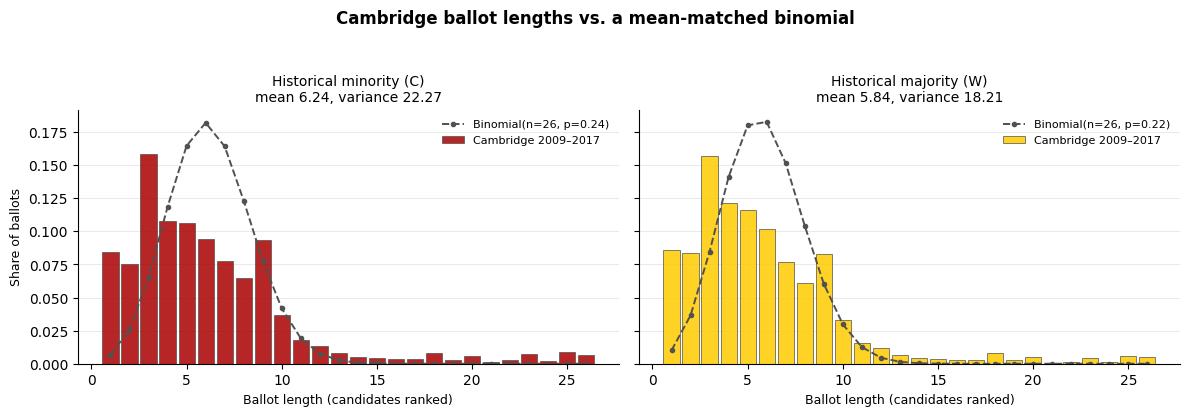

In [3]:
def fitted_binomial(pmf: pd.Series) -> tuple[pd.Series, int, float]:
    """Binomial over 1..n_max matched on the mean (n fixed at the longest ballot)."""
    n = int(pmf.index.max())
    mean = float((pmf.index.to_numpy(dtype=float) * pmf.to_numpy()).sum())
    p = mean / n
    support = np.arange(1, n + 1)
    probs = binom.pmf(support, n, p)
    return pd.Series(probs / probs.sum(), index=support), n, p


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, (tag, pmf) in zip(axes, by_start.items()):
    fit, n, p = fitted_binomial(pmf)
    ax.bar(
        pmf.index, pmf.to_numpy(), width=0.85,
        color=MODE_COLORS["slate_pl"] if tag == "W" else MODE_COLORS["slate_bt"],
        edgecolor=BAR_EDGE_COLOR, linewidth=0.6, alpha=0.85, label="Cambridge 2009–2017",
    )
    ax.plot(fit.index, fit.to_numpy(), color="#52514e", linewidth=1.4, linestyle="--",
            marker="o", markersize=3, label=f"Binomial(n={n}, p={p:.2f})")
    m = moments(pmf)
    ax.set_title(f"{HIST_SLATES[tag]}\nmean {m['mean']:.2f}, variance {m['variance']:.2f}",
                 fontsize=10)
    ax.set_xlabel("Ballot length (candidates ranked)", fontsize=9)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linewidth=0.5, color="#e1e0d9")
    ax.set_axisbelow(True)
axes[0].set_ylabel("Share of ballots", fontsize=9)
fig.suptitle("Cambridge ballot lengths vs. a mean-matched binomial",
             fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

The empirical distribution is right-skewed with a mode at 3 and a fat tail that
a binomial cannot produce: its variance is roughly four times what a binomial
of the same mean allows. The spikes near the maximum are voters who ranked
essentially the whole field.

A geometric-style distribution is the better description — the table below
reports the variance-to-mean ratio, which is 1 for a Poisson, below 1 for a
binomial, and well above 1 here.

In [4]:
comparison = []
for tag, pmf in by_start.items():
    fit, n, p = fitted_binomial(pmf)
    m = moments(pmf)
    comparison.append({
        "slice": HIST_SLATES[tag],
        "mean": round(m["mean"], 2),
        "empirical variance": round(m["variance"], 2),
        "binomial variance": round(n * p * (1 - p), 2),
        "overdispersion": round(m["variance"] / (n * p * (1 - p)), 1),
        "P(length ≤ 3)": round(float(pmf.loc[pmf.index <= 3].sum()), 3),
        "P(length ≥ 10)": round(float(pmf.loc[pmf.index >= 10].sum()), 3),
    })
pd.DataFrame(comparison).set_index("slice")

,mean,empirical variance,binomial variance,overdispersion,P(length ≤ 3),P(length ≥ 10)
slice,,,,,,
Historical minority (C),6.24,22.27,4.74,4.7,0.318,0.139
Historical majority (W),5.84,18.21,4.53,4.0,0.326,0.114


## What this project would actually see

The historical ballots are longer than any district in this study has
candidates, so `_reduce_ballot` truncates them: it walks the ballot and drops
any slate mention past that slate's candidate count. With 2 W and 2 C
candidates, `WWWCCWWCC` becomes `WWCC`.

That is the distribution a San Diego run would sample from, and it is far
shorter than the raw historical one.

configured slate sizes: {'WHI': 4, 'BAIO': 2, 'HIS': 3, 'AAPI': 2}


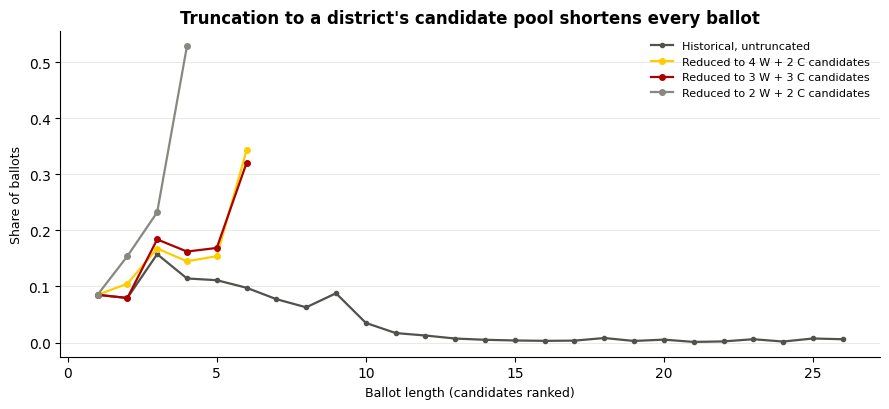

In [5]:
def reduce_ballot(ballot: str, w_count: int, c_count: int) -> str:
    """Port of votekit's _reduce_ballot: keep each slate only up to its candidate count."""
    out, w_left, c_left = [], w_count, c_count
    for char in ballot:
        if char == "W" and w_left > 0:
            out.append("W"); w_left -= 1
        elif char == "C" and c_left > 0:
            out.append("C"); c_left -= 1
    return "".join(out)


config = load_run_config(PROJECT_DIR / "configs/basic.json")
slate_sizes = {s: len(c) for s, c in config["slate_to_candidates"].items()}
print("configured slate sizes:", slate_sizes)

# Cambridge is a two-slate model, so a run maps its focal slate to one historical
# slate and the rest to the other. Sizes here bracket what this project uses.
scenarios = [(4, 2), (3, 3), (2, 2)]

fig, ax = plt.subplots(figsize=(9, 4.2))
raw = overall
ax.plot(raw.index, raw.to_numpy(), color=BAR_EDGE_COLOR, linewidth=1.6,
        marker="o", markersize=3, label="Historical, untruncated")
for (w_count, c_count), color in zip(scenarios, ("#FFCC00", "#AA0000", "#898781")):
    reduced = ballots.assign(
        length=[len(reduce_ballot(b, w_count, c_count)) for b in ballots["ballot_type"]]
    )
    pmf = length_pmf(reduced)
    ax.plot(pmf.index, pmf.to_numpy(), marker="o", markersize=4, linewidth=1.6,
            color=color, label=f"Reduced to {w_count} W + {c_count} C candidates")
ax.set_xlabel("Ballot length (candidates ranked)", fontsize=9)
ax.set_ylabel("Share of ballots", fontsize=9)
ax.set_title("Truncation to a district's candidate pool shortens every ballot",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linewidth=0.5, color="#e1e0d9")
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

In [6]:
rows = []
for w_count, c_count in scenarios:
    reduced = ballots.assign(
        length=[len(reduce_ballot(b, w_count, c_count)) for b in ballots["ballot_type"]]
    )
    pmf = length_pmf(reduced)
    m = moments(pmf)
    rows.append({
        "candidate pool": f"{w_count} W + {c_count} C",
        "max possible length": w_count + c_count,
        "mean length": round(m["mean"], 2),
        "variance": round(m["variance"], 2),
        "P(full ballot)": round(float(pmf.get(w_count + c_count, 0.0)), 3),
    })
pd.DataFrame(rows).set_index("candidate pool")

,max possible length,mean length,variance,P(full ballot)
candidate pool,,,,
4 W + 2 C,6,4.21,2.84,0.343
3 W + 3 C,6,4.21,2.67,0.320
2 W + 2 C,4,3.20,0.98,0.529
